In [62]:
# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cns.data_utils import load_all_samples, img_path
from cns.utils.cutoff import count_below_lim, find_knee
file_type = ".pdf"

In [64]:
plt.rcParams.update({'font.size': 12, 'figure.figsize': (5, 5)})

In [65]:
data = load_all_samples(False, False, False, True)
datasets = list(data.keys())
colors = {"PCAWG": "C0", "TCGA_hg19": "C1", "TRACERx": "C2"}

In [66]:
data["TRACERx"]

,sex,type,chrom_count,chrom_missing,cover_bases_aut,cover_bases_sex,cover_bases_tot,cover_frac_aut,cover_frac_sex,cover_frac_tot,...,ane_major_cn_frac_aut,ane_minor_cn_frac_aut,ane_total_cn_frac_aut,ane_major_cn_sex,ane_minor_cn_sex,ane_total_cn_sex,ane_major_cn_frac_sex,ane_minor_cn_frac_sex,ane_total_cn_frac_sex,dataset
sample_id,,,,,,,,,,,,,,,,,,,,,
CRUK0034_SU_T1-R1,xx,LUAD,22,['chrX'],2662078662,0,2662078662,0.924001,0.0,0.876750,...,0.975738,0.516650,0.926728,155270560,155270560,155270560,1.0,1.0,1.0,primary
CRUK0034_SU_T1-R2,xx,LUAD,22,['chrX'],2662078662,0,2662078662,0.924001,0.0,0.876750,...,0.951686,0.465789,0.891072,155270560,155270560,155270560,1.0,1.0,1.0,primary
CRUK0034_SU_T1-R3,xx,LUAD,22,['chrX'],2662078662,0,2662078662,0.924001,0.0,0.876750,...,0.975803,0.686332,0.938044,155270560,155270560,155270560,1.0,1.0,1.0,primary
CRUK0150_SU_T1-R1,xy,Other,22,['chrX' 'chrY'],2539146321,0,2539146321,0.881332,0.0,0.820223,...,0.992954,0.848752,0.983817,214644126,0,214644126,1.0,0.0,1.0,primary
CRUK0150_SU_T1-R2,xy,Other,22,['chrX' 'chrY'],2539146321,0,2539146321,0.881332,0.0,0.820223,...,0.999857,0.890716,0.977088,214644126,0,214644126,1.0,0.0,1.0,primary
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CRUK0745_SU_FLN4,xy,LUAD,22,['chrX' 'chrY'],2558080862,0,2558080862,0.887904,0.0,0.826340,...,0.755202,0.494102,0.543355,214644126,0,214644126,1.0,0.0,1.0,metastatic
CRUK0872_SU_FLN1,xy,LUSC,22,['chrX' 'chrY'],2655276392,0,2655276392,0.921640,0.0,0.857737,...,0.998797,0.829994,0.754459,214644126,0,214644126,1.0,0.0,1.0,metastatic
CRUK0817_BR_T1-R1,xy,LUAD,22,['chrX' 'chrY'],2604858920,0,2604858920,0.904141,0.0,0.841450,...,1.000000,0.829770,0.992572,214644126,0,214644126,1.0,0.0,1.0,metastatic


In [67]:
ane_count = {}
ane_cutoffs = {}
ane_deltas = {}
feature = "ane_total_cn_frac_aut"
max_val = 0.01
for k, v in data.items():
    ane_cutoffs[k], ane_count[k], ane_deltas[k] = count_below_lim(v[feature], max_val=max_val, steps=100)

101 0.01 0.13174946004319654
PCAWG 16 35.422565006156134
101 0.01 0.0012345679012345679
TRACERx 11 0.04366389911698259
101 0.01 0.11542359140656668
TCGA_hg19 10 52.501999265861215


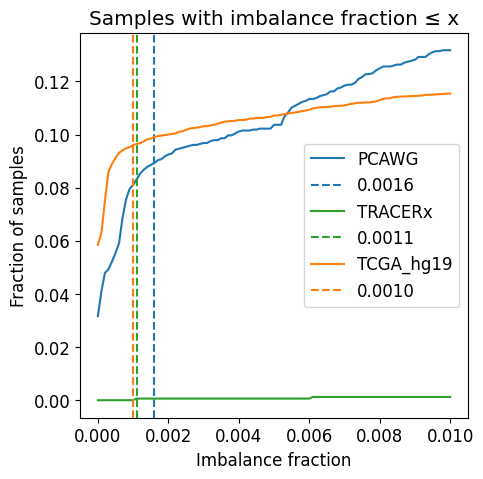

In [68]:
for k, v in ane_count.items():
    plt.plot(ane_cutoffs[k], v, label=k, color=colors[k])    
    if  np.max(v) <= 0:
        continue
    print(len(v), np.max(ane_cutoffs[k]), np.max(v))
    knee_index, knee_value = find_knee(v, ane_deltas[k], convex=True, dist=10)
    print(k, knee_index, knee_value)
    x_pos = ane_cutoffs[k][knee_index]
    plt.axvline(x_pos, color=colors[k], linestyle="--", label=f"{x_pos:.4f}")
    
plt.xlabel("Imbalance fraction")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title(f"Samples with imbalance fraction ≤ x")
plt.savefig(f"{img_path}/fig_samples_imbalance_fraction{file_type}", bbox_inches="tight")

In [69]:
cov_count = {}
cov_cutoffs = {}
cov_deltas = {}
feature = "cover_frac_aut"
min_val = 0.75
for k, v in data.items():
    cov_cutoffs[k], cov_count[k], cov_deltas[k] = count_below_lim(v[feature], min_val=min_val, steps=250)

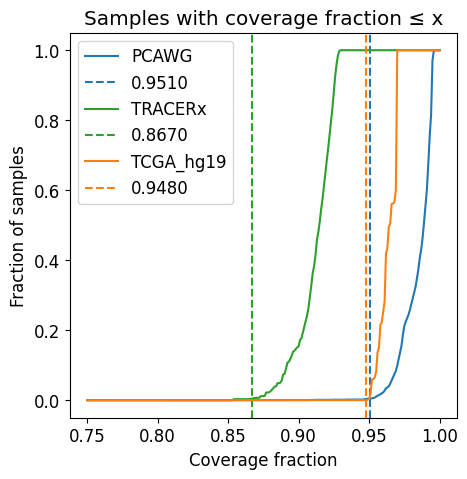

In [70]:
for k, v in cov_count.items():
    plt.plot(cov_cutoffs[k], v, label=k, color=colors[k])        
    knee_index, knee_value = find_knee(v, cov_deltas[k], convex=False, dist=10)
    x_pos = cov_cutoffs[k][knee_index]
    plt.axvline(x_pos, color=colors[k], linestyle="--", label=f"{x_pos:.4f}")

plt.xlabel("Coverage fraction")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title(f"Samples with coverage fraction ≤ x")
plt.savefig(f"{img_path}/fig_samples_coverage_fraction{file_type}", bbox_inches="tight")

In [71]:
break_count = {}
break_cutoffs = {}
break_deltas = {}
feature = "breaks_aut"
steps = 250
for k, v in data.items():
    break_cutoffs[k], break_count[k], break_deltas[k] = count_below_lim(v[feature], max_val=steps, steps=steps)

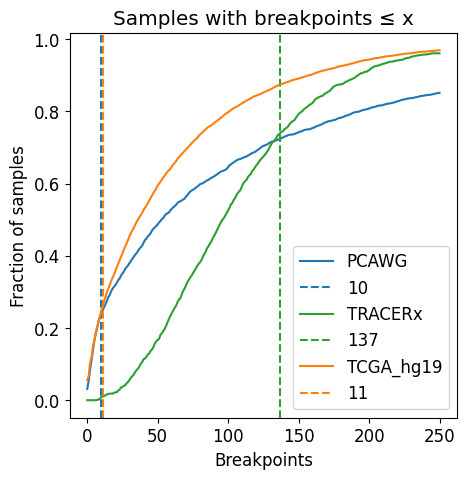

In [72]:
for k, v in break_count.items():
    plt.plot(break_cutoffs[k], v, label=k, color=colors[k])        
    knee_index, knee_value = find_knee(v, break_deltas[k], convex=True, dist=10)
    x_pos = break_cutoffs[k][knee_index]
    plt.axvline(x_pos, color=colors[k], linestyle="--", label=f"{int(x_pos)}")

plt.ylabel("Fraction of samples")
plt.xlabel("Breakpoints")
plt.title(f"Samples with breakpoints ≤ x")
plt.legend()
plt.savefig(f"{img_path}/fig_samples_breaks_fraction{file_type}", bbox_inches="tight")